In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import json
import os

In [11]:
model=ChatOpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    model_name="mistralai/mistral-nemotron",
    api_key=os.getenv("NVIDIA_API_KEY")
)

In [12]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [13]:
def generate_joke(state:JokeState):

    prompt=f"generate a joke on the topic {state['topic']}"
    response=model.invoke(prompt).content


    return {'joke':response}

In [14]:
def generate_explanation(state:JokeState):

    prompt=f"write an explanation for the joke -{state['joke']}"
    response=model.invoke(prompt).content
    return{'explanation':response}

In [15]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)

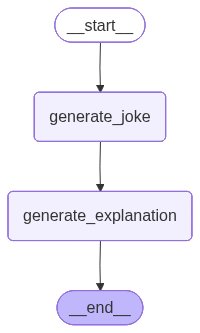

In [16]:
workflow

In [18]:
config1={'configurable':{'thread_id':'1'}}
workflow.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza get hired as a detective?\n\nBecause it knew how to *crust* the case! 🕵️\u200d♂️🍕',
 'explanation': 'Here’s an explanation for the joke:\n\n**Joke:**\n*Why did the pizza get hired as a detective?*\n**Because it knew how to crust the case!** 🕵️\u200d♂️🍕\n\n---\n### **Explanation:**\nThis joke is a playful example of a **pun**, where a word with multiple meanings is used to create humor.\n\n1. **Crust (Noun)** – In a pizza, the *crust* is the hard outer edge of the bread.\n   - *Example:* "I love eating the crispy crust of my pizza!"\n\n2. **Crust (Verb, in a Phrasal Form)** – If you *crust* something (like a case), it sounds similar to the phrase **"bust the case"**, which means to solve or crack a difficult mystery. This is a clever twist using the word *crust* as a replacement for *bust*.\n\n3. **Why It’s Funny** – The humor comes from the surprise when the word *crust* (from pizza) is used in place of *bust* (as detectives do). The unexp

In [19]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get hired as a detective?\n\nBecause it knew how to *crust* the case! 🕵️\u200d♂️🍕', 'explanation': 'Here’s an explanation for the joke:\n\n**Joke:**\n*Why did the pizza get hired as a detective?*\n**Because it knew how to crust the case!** 🕵️\u200d♂️🍕\n\n---\n### **Explanation:**\nThis joke is a playful example of a **pun**, where a word with multiple meanings is used to create humor.\n\n1. **Crust (Noun)** – In a pizza, the *crust* is the hard outer edge of the bread.\n   - *Example:* "I love eating the crispy crust of my pizza!"\n\n2. **Crust (Verb, in a Phrasal Form)** – If you *crust* something (like a case), it sounds similar to the phrase **"bust the case"**, which means to solve or crack a difficult mystery. This is a clever twist using the word *crust* as a replacement for *bust*.\n\n3. **Why It’s Funny** – The humor comes from the surprise when the word *crust* (from pizza) is used in place of *bust* (as detect

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get hired as a detective?\n\nBecause it knew how to *crust* the case! 🕵️\u200d♂️🍕', 'explanation': 'Here’s an explanation for the joke:\n\n**Joke:**\n*Why did the pizza get hired as a detective?*\n**Because it knew how to crust the case!** 🕵️\u200d♂️🍕\n\n---\n### **Explanation:**\nThis joke is a playful example of a **pun**, where a word with multiple meanings is used to create humor.\n\n1. **Crust (Noun)** – In a pizza, the *crust* is the hard outer edge of the bread.\n   - *Example:* "I love eating the crispy crust of my pizza!"\n\n2. **Crust (Verb, in a Phrasal Form)** – If you *crust* something (like a case), it sounds similar to the phrase **"bust the case"**, which means to solve or crack a difficult mystery. This is a clever twist using the word *crust* as a replacement for *bust*.\n\n3. **Why It’s Funny** – The humor comes from the surprise when the word *crust* (from pizza) is used in place of *bust* (as detec

In [23]:
config2={'configurable':{'thread_id':'1'}}
workflow.invoke({'topic':'pasta'},config=config2)

{'topic': 'pasta',
 'joke': "Sure! Here's a pasta-themed joke for you:\n\n**Why did the pasta break up with the sauce?**\nBecause it found someone *more a-peeling*! 🍝😂\n\n(And now it’s a *gnocci* gnocci joke—get it?)\n\nBonus: If you like this, try telling it over a romantic *carbonara* dinner!",
 'explanation': 'Here’s a breakdown of the pasta joke and why it’s funny:\n\n### **Joke:**\n**"Why did the pasta break up with the sauce?**\n**Because it found someone *more a-peeling*!"**\n\n### **Explanation:**\n1. **"More a-peeling"** – This is a pun combining two meanings:\n   - **"A-peeling"** (sounds like "appealing") suggests the pasta found someone more attractive.\n   - **"Peeling"** also refers to removing layers (like peeling potatoes or onions), which nods to the fact that **gnocchi** (a type of pasta) is made from potatoes.\n     *(_connéudin_ to the later pun on "gnocchi" in the joke.)*\n\n2. **"And now it’s a *gnocci* gnocci joke—get it?"** – This is a self-aware twist:\n   - Th

In [24]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': "Sure! Here's a pasta-themed joke for you:\n\n**Why did the pasta break up with the sauce?**\nBecause it found someone *more a-peeling*! 🍝😂\n\n(And now it’s a *gnocci* gnocci joke—get it?)\n\nBonus: If you like this, try telling it over a romantic *carbonara* dinner!", 'explanation': 'Here’s a breakdown of the pasta joke and why it’s funny:\n\n### **Joke:**\n**"Why did the pasta break up with the sauce?**\n**Because it found someone *more a-peeling*!"**\n\n### **Explanation:**\n1. **"More a-peeling"** – This is a pun combining two meanings:\n   - **"A-peeling"** (sounds like "appealing") suggests the pasta found someone more attractive.\n   - **"Peeling"** also refers to removing layers (like peeling potatoes or onions), which nods to the fact that **gnocchi** (a type of pasta) is made from potatoes.\n     *(_connéudin_ to the later pun on "gnocchi" in the joke.)*\n\n2. **"And now it’s a *gnocci* gnocci joke—get it?"** – This is a self-aw

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pasta', 'joke': "Sure! Here's a pasta-themed joke for you:\n\n**Why did the pasta break up with the sauce?**\nBecause it found someone *more a-peeling*! 🍝😂\n\n(And now it’s a *gnocci* gnocci joke—get it?)\n\nBonus: If you like this, try telling it over a romantic *carbonara* dinner!", 'explanation': 'Here’s a breakdown of the pasta joke and why it’s funny:\n\n### **Joke:**\n**"Why did the pasta break up with the sauce?**\n**Because it found someone *more a-peeling*!"**\n\n### **Explanation:**\n1. **"More a-peeling"** – This is a pun combining two meanings:\n   - **"A-peeling"** (sounds like "appealing") suggests the pasta found someone more attractive.\n   - **"Peeling"** also refers to removing layers (like peeling potatoes or onions), which nods to the fact that **gnocchi** (a type of pasta) is made from potatoes.\n     *(_connéudin_ to the later pun on "gnocchi" in the joke.)*\n\n2. **"And now it’s a *gnocci* gnocci joke—get it?"** – This is a self-a

In [27]:
workflow.get_state({'configurable':{'thread_id':'1','checkpoint_id':'1f159098-9858-687c-8000-087ff5f22413'}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f159098-9858-687c-8000-087ff5f22413'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-26T13:48:12.200336+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f159098-9832-6353-bfff-58f41766628b'}}, tasks=(PregelTask(id='a43348db-f0a0-6f74-a214-f7bc7c16161e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error='BadRequestError(\'Error code: 400 - {\\\'status\\\': 400, \\\'title\\\': \\\'Bad Request\\\', \\\'detail\\\': "Function id \\\'f81394d8-63c0-4023-afa2-7ad11aa54ca3\\\': DEGRADED function cannot be invoked"}\')', interrupts=(), state=None, result=None),), interrupts=())

In [30]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1590e4-aab4-605e-8000-aec082dff5b9'}}

In [ ]:
workflow.invoke(None,{"configurable": {"thread_id": "1", "checkpoint_id": "1f1590e4-aab4-605e-8000-aec082dff5b9"}})